In [1]:
%load_ext autoreload
%autoreload 2

import torch
import astra
import numpy as np
import time
from matplotlib import pyplot as plt

from uqct.datasets.tomogram_dataset import TomogramDataset
from uqct.datasets.tiff_tomogram_dataset import TIFFDataset
from uqct.datasets.nii_tomogram_dataset import NiiDataset
from uqct.datasets.nii_tomogram_dataset import NiiDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def get_dataset(kwargs, dataset_type):
    dataset_class = TomogramDataset if dataset_type == 'h5' else TIFFDataset
    dataset_class = NiiDataset if dataset_type == 'nii' else dataset_class

    if dataset_type == 'tiff' and 'im_size' not in kwargs:
        kwargs['im_size'] = 512

    if dataset_type == 'nii' and 'clip_range' not in kwargs:
        kwargs['im_size'] = 512
        kwargs['clip_range'] = [3e4, 5e4]

    dataset = dataset_class(**kwargs)
    torch.manual_seed(0)
    perm = torch.randperm(len(dataset))
    trainSet = torch.utils.data.Subset(dataset, perm[:round(0.95 * len(dataset))])
    testSet = torch.utils.data.Subset(dataset, perm[round(0.95 * len(dataset)):])
    return trainSet, testSet

def get_astra_geometry_3d(angles, im_size, n_slices):
    # ASTRA 3D geometries
    angles_rad = -torch.deg2rad(angles).detach().cpu().numpy() 
    det_spacing_x = 1.0
    det_spacing_y = 1.0
    n_det_cols = int(im_size)
    n_det_rows = int(n_slices)

    proj_geom3d = astra.create_proj_geom('parallel3d',
                                         det_spacing_y, det_spacing_x,
                                         n_det_rows, n_det_cols,
                                         angles_rad)
    # ASTRA uses (nx, ny, nz) order
    vol_geom3d = astra.create_vol_geom(im_size, im_size, int(n_slices))

    return proj_geom3d, vol_geom3d


class AstraParallelOp3D:
    """
    Torch ⇄ ASTRA 3D parallel-beam operator (GPU preferred).
    Volume: (nz, ny, nx)
    Sinogram: (n_angles, n_det_y, n_det_x)
    """
    def __init__(self, vol_geom, proj_geom):
        self.vol_geom  = vol_geom
        self.proj_geom = proj_geom
        self.nz, self.ny, self.nx = vol_geom['GridRowCount'], vol_geom['GridColCount'], vol_geom['GridSliceCount']
        self.n_angles = proj_geom['ProjectionAngles'].shape[0]
        self.n_det_y  = proj_geom['DetectorRowCount']
        self.n_det_x  = proj_geom['DetectorColCount']

    def forward(self, vol_t: torch.Tensor, out_sino_t: torch.Tensor | None = None):
        # vol_t: (nz, ny, nx)
        if out_sino_t is None:
            out_sino_t = torch.empty((self.n_det_y, self.n_angles,  self.n_det_x),
                                     device=vol_t.device, dtype=torch.float32)

        vol_id  = astra.data3d.link('-vol',  self.vol_geom, vol_t.detach())
        sino_id = astra.data3d.link('-sino', self.proj_geom, out_sino_t.detach())

        try:
            cfg = astra.astra_dict('FP3D_CUDA')
        except Exception:
            cfg = astra.astra_dict('FP3D')
        cfg['VolumeDataId']     = vol_id
        cfg['ProjectionDataId'] = sino_id
        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id, 1)
        astra.algorithm.delete(alg_id)
        astra.data3d.delete(sino_id)
        astra.data3d.delete(vol_id)
        return out_sino_t

    def adjoint(self, sino_t: torch.Tensor, out_vol_t: torch.Tensor | None = None):
        # sino_t: (n_angles, n_det_y, n_det_x)
        if out_vol_t is None:
            out_vol_t = torch.zeros((self.nz, self.ny, self.nx), device=sino_t.device, dtype=torch.float32)

        vol_id  = astra.data3d.link('-vol',  self.vol_geom, out_vol_t.detach())
        sino_id = astra.data3d.link('-sino', self.proj_geom, sino_t.detach())
        try:
            cfg = astra.astra_dict('BP3D_CUDA')
        except Exception:
            cfg = astra.astra_dict('BP3D')
        cfg['ReconstructionDataId'] = vol_id
        cfg['ProjectionDataId']     = sino_id
        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id, 1)
        astra.algorithm.delete(alg_id)
        astra.data3d.delete(sino_id)
        astra.data3d.delete(vol_id)
        return out_vol_t

def make_radon_layer(op: AstraParallelOp3D):
    """
    Autograd wrapper.
    Input:  x (B, nz, ny, nx)
    Output: y (B, n_angles, n_det_y, n_det_x)
    """
    class ParallelBeam3DFn(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            y = op.forward(x)
            ctx.op = op
            return y

        @staticmethod
        def backward(ctx, grad_out):
            op = ctx.op

            g_vol = torch.zeros((op.nz, op.ny, op.nx), device=grad_out.device, dtype=torch.float32)
            op.adjoint(grad_out.detach(), g_vol)
            return g_vol

    return ParallelBeam3DFn.apply


def compute_sinogram(images, vol_geom_3d, proj_geom_3d):
    batch_dims = images.size()[:-2]
    img_shape = images.size()[-2:]
    images = images.view(-1, *img_shape)

    op3d = AstraParallelOp3D(vol_geom_3d, proj_geom_3d)
    parallel3d_layer = make_radon_layer(op3d)

    sinogram = parallel3d_layer(images.squeeze())

    return sinogram.view(*batch_dims, sinogram.shape[1], img_shape[0])

In [3]:
DATA_PATH = '/mydata/chip/shared/data' if torch.cuda.is_available() else '../data'
kwargs_lamino = {
        'path': '/mydata/chip/shared/data/lamino_tiff',
        'rescale': 128,
        'im_size': 256,
        'train_transform':False,
        'rotation_angle':30,
        'normalize_range':True
    }

kwargs_lung = {
        'path': '/mydata/chip/shared/data/lung/ground_truth_train',
        'rescale': 128,
        # 'im_size': 256,
        'train_transform':False,
        'rotation_angle':30,
        'normalize_range':True
}

kwargs_composite = {
        'path': '/mydata/chip/shared/data/composite/SampleG-FBI22-Stitch-0-1-2.txm.nii',
        'rescale': 128,
        'im_size': 256,
        'train_transform':False,
        'file_range':[20,360],
        'clip_range':[3e4, 5e4],
                'rotation_angle':30,
        'normalize_range':True
    }

In [4]:
trainSet, testSet_lamino = get_dataset(kwargs_lamino, 'tiff')
trainSet, testSet_composite = get_dataset(kwargs_composite, 'nii')
trainSet, testSet_lung = get_dataset(kwargs_lung, 'h5')

In [5]:
images = torch.stack([
    testSet_lamino[0],
    testSet_lamino[1],
    testSet_composite[0],
    testSet_composite[1],
    testSet_lung[2],
    testSet_lung[1],
]).to(device).unsqueeze(1)  # shape: (6, 1, 1, 128, 128)
images.shape



torch.Size([6, 1, 1, 128, 128])

min/max of image 0: 0.0/1.0
min/max of image 1: 0.0/1.0
min/max of image 2: 0.0/1.0
min/max of image 3: 0.0/1.0
min/max of image 4: 0.0/1.0
min/max of image 5: 0.0/1.0


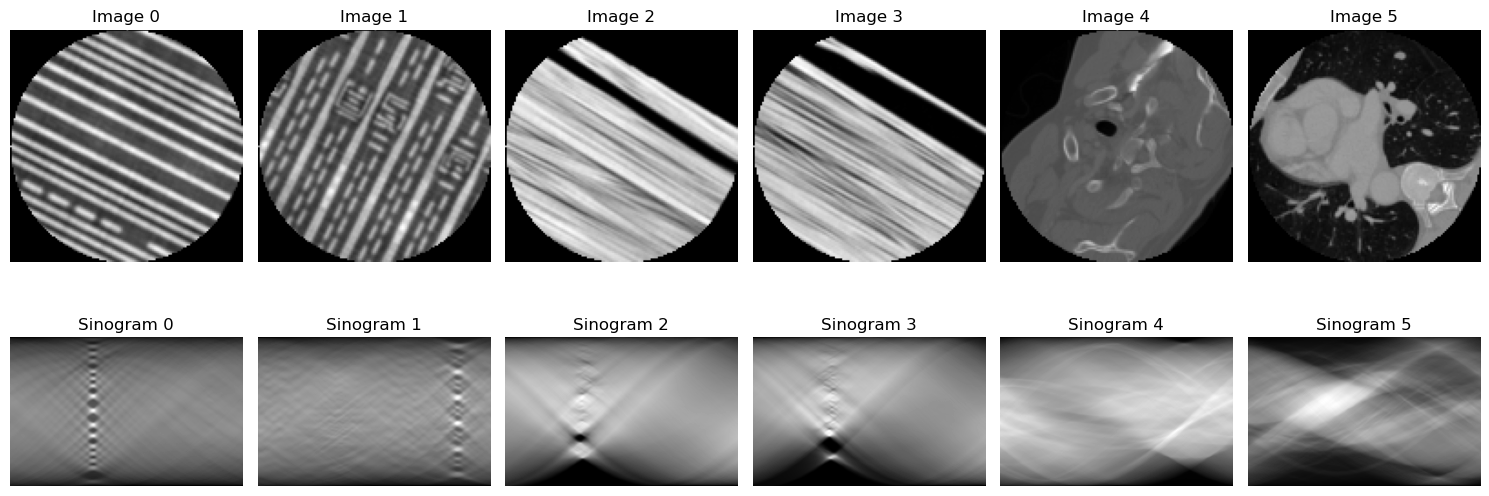

In [6]:
num_angles = 200
angles = torch.from_numpy(np.linspace(0, 180, num_angles, endpoint=False)   )

# Define angles and geometry
proj_geom3d, vol_geom3d = get_astra_geometry_3d(angles, 128, n_slices=len(images))    

sinogram = compute_sinogram(images, vol_geom3d, proj_geom3d)


fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(6):
    print(f"min/max of image {i}: {images[i].min().item()}/{images[i].max().item()}")
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[1, i].set_title(f'Sinogram {i}')
    axes[1, i].axis('off')


plt.tight_layout()
plt.show()

torch.Size([66, 128, 200])
ASTRA using GPU for FBP
FBP ASTRA time: 0.010 s


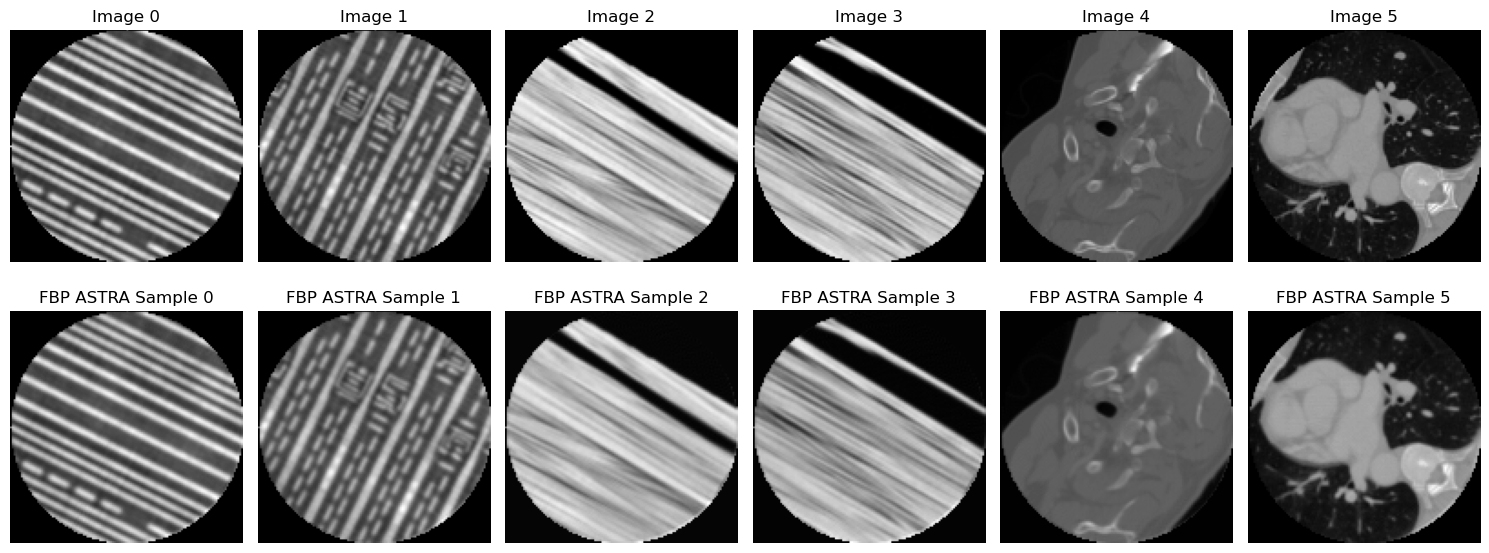

In [11]:

def _fourier_filter_1d(size: int, filter_name: str, device=None, dtype=torch.float32) -> torch.Tensor:
    if filter_name not in ('ramp', 'shepp-logan', 'cosine', 'hamming', 'hann', None):
        raise ValueError(f"Unknown filter: {filter_name}")
    device = device or torch.device('cpu')
    size = int(size)

    n1 = torch.arange(1, size // 2 + 1, 2, device=device)
    n2 = torch.arange(size // 2 - 1, 0, -2, device=device)
    n = torch.cat([n1, n2], dim=0).to(torch.float64)

    f = torch.zeros(size, dtype=torch.float64, device=device)
    f[0] = 0.25
    f[1::2] = -1.0 / (torch.pi * n) ** 2

    fourier_filter = 2.0 * torch.real(torch.fft.fft(f))  # ramp

    if filter_name == "ramp":
        pass
    elif filter_name == "shepp-logan":
        omega = torch.pi * torch.fft.fftfreq(size, device=device, dtype=torch.float64)[1:]
        fourier_filter[1:] *= torch.sin(omega) / torch.where(omega == 0, torch.ones_like(omega), omega)
    elif filter_name == "cosine":
        # freq in [0, pi)
        freq = torch.arange(size, device=device, dtype=torch.float64) * (torch.pi / size)
        fourier_filter *= torch.fft.fftshift(torch.sin(freq))
    elif filter_name == "hamming":
        win = torch.hamming_window(size, periodic=False, dtype=torch.float64, device=device)
        fourier_filter *= torch.fft.fftshift(win)
    elif filter_name == "hann":
        win = torch.hann_window(size, periodic=False, dtype=torch.float64, device=device)
        fourier_filter *= torch.fft.fftshift(win)
    elif filter_name is None:
        fourier_filter[:] = 1.0

    return fourier_filter.to(dtype).reshape(size, 1)

def _apply_filter_batch(sino: torch.Tensor, filter_name: str) -> torch.Tensor:
    """
    sino: (B, M, N) float32 or (M, N) float32 torch tensor.
    Returns same shape as input, torch tensor.
    """
    if not isinstance(sino, torch.Tensor):
        raise TypeError("sino must be a torch.Tensor")
    single = (sino.ndim == 2)
    if single:
        sino = sino.unsqueeze(0)  # (1, M, N)
    B, M, N = sino.shape
    device = sino.device
    dtype = sino.dtype

    projection_size_padded = max(64, int(2 ** np.ceil(np.log2(2 * M))))
    P = projection_size_padded

    # pad along detector axis (dim=1) at the end
    sino_padded = torch.zeros((B, P, N), device=device, dtype=dtype)
    sino_padded[:, :M, :] = sino

    filt = _fourier_filter_1d(P, filter_name, device=device, dtype=dtype)  # (P,1)
    filt = filt.view(1, P, 1)

    proj_fft = torch.fft.fft(sino_padded, dim=1)
    proj_fft = proj_fft * filt
    sino_filt = torch.real(torch.fft.ifft(proj_fft, dim=1)).to(dtype)
    sino_filt = sino_filt[:, :M, :]

    return sino_filt[0] if single else sino_filt

def _circular_mask(img_size: int, device=None, dtype=torch.float32) -> torch.Tensor:
    device = device or torch.device('cpu')
    yy, xx = torch.meshgrid(
        torch.arange(img_size, device=device),
        torch.arange(img_size, device=device),
        indexing='ij'
    )
    r = img_size // 2
    mask = ((yy - r) ** 2 + (xx - r) ** 2 <= r ** 2).to(dtype)
    return mask

def iradon_astra(radon_image: torch.Tensor,
                 vol_geom3d,
                 proj_geom3d,
                 output_size: int | None = None,
                 filter_name: str = "ramp",
                 circle: bool = True) -> torch.Tensor:
    """
    Torch-only I/O fast FBP using ASTRA's 3D backprojection to handle a batch of 2D sinograms.
    Input:  (M, N) or (B, M, N) torch float tensor 
    Output: (H, W) or (B, H, W) torch float32 tensor.
    """
    if not isinstance(radon_image, torch.Tensor):
        raise TypeError("radon_image must be a torch.Tensor")
    if radon_image.ndim not in (2, 3):
        raise ValueError("radon_image must be 2-D (M,N) or 3-D (B,M,N)")
    single = (radon_image.ndim == 2)
    if single:
        radon_image = radon_image.unsqueeze(0)  # (1, M, N)

    # dtype and device handling
    radon_image = radon_image.detach()
    if radon_image.dtype not in (torch.float32, torch.float64):
        radon_image = radon_image.float()
    # ASTRA expects CPU-linked arrays
    radon_image = radon_image.contiguous()#.cpu()

    B, M, N = radon_image.shape

    # Filter in frequency domain
    sino_filt = _apply_filter_batch(radon_image, filter_name)  # (B, M, N)

    # Output size
    if output_size is None:
        output_size = int(M)
    output_size = int(output_size)

    # Reorder for ASTRA: (n_det_rows, n_angles, n_det_cols)
    sino_3d = sino_filt.permute(0, 2, 1).contiguous()  # torch tensor (B, N, M) CPU float

    # Preallocate output and link both
    vol = torch.zeros((B, output_size, output_size), dtype=torch.float32, device=radon_image.device)
    sino_id = astra.data3d.link('-sino', proj_geom3d, sino_3d)
    vol_id  = astra.data3d.link('-vol',  vol_geom3d, vol)

    try:
        try:
            cfg = astra.astra_dict('BP3D_CUDA')
            print("ASTRA using GPU for FBP")
        except Exception:
            cfg = astra.astra_dict('BP3D')
        cfg['ReconstructionDataId'] = vol_id
        cfg['ProjectionDataId']     = sino_id
        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id, 1)
        astra.algorithm.delete(alg_id)
    finally:
        astra.data3d.delete([sino_id, vol_id])

    # Scale to match skimage.iradon
    scale = np.pi / (2.0 * float(N))
    vol.mul_(float(scale))

    if circle:
        mask = _circular_mask(output_size, device=vol.device, dtype=vol.dtype)  # (H,W)
        vol *= mask.unsqueeze(0)

    return vol[0] if single else vol
# ...existing code...

_sinogram = sinogram.swapaxes(-1, -2).squeeze().to(device).repeat(11, 1, 1).clone()
# _sinogram = torch.randn_like(_sinogram)

proj_geom3d, vol_geom3d = get_astra_geometry_3d(angles, 128, n_slices=len(_sinogram))

print(_sinogram.shape)
t0 = time.time()

with torch.no_grad():
    fbp_astra = iradon_astra(_sinogram, vol_geom3d, proj_geom3d, filter_name='ramp', circle=True)
print(f"FBP ASTRA time: {time.time()-t0:.3f} s")

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(6):
    # metrics = get_metrics(fbp_astra[i], images[i].cpu().squeeze())
    # print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {fbp_astra[i].min()}/{fbp_astra[i].max()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(fbp_astra[i].cpu(), cmap='gray')
    axes[1, i].set_title(f'FBP ASTRA Sample {i}')
    axes[1, i].axis('off')
plt.tight_layout()